# Lyrics Analysis: Predicting Genre with Naive Bayes

In this notebook, we focus on **Multinomial Naive Bayes**, the industry standard for text analysis, to explore **Genre Classification**: Predicting a song's genre based on its lyrical themes.

The central hypothesis is that lyrics contain nuanced indicators of a song's genre, as different musical styles often employ distinct vocabularies and thematic elements.

### 1) Data Acquisition via KaggleHub

To ensure the project is reproducible and uses the most up-to-date information, the `kagglehub` library is used to programmatically download the datasets directly into the local environment.

In [84]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Natural Language Processing (NLP) tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download the dataset
path = kagglehub.dataset_download("evabot/spotify-lyrics-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Philipp\.cache\kagglehub\datasets\evabot\spotify-lyrics-dataset\versions\1


### 2) Loading Lyrics

Working with lyrics presents a distinct set of challenges. A robust loading logic handles different separators and missing data, prioritizing rows that contain actual lyrics.

In [85]:
# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
lyrics_file_name = next((f for f in csv_files if 'lyrics' in f.lower()), csv_files[0])
lyrics_file_path = os.path.join(path, lyrics_file_name)

# Load the CSV with robust error handling
try:
    df_lyrics = pd.read_csv(lyrics_file_path, sep=';', decimal=',', on_bad_lines='skip')
    if 'lyrics' not in df_lyrics.columns and 'Lyrics' in df_lyrics.columns:
        df_lyrics = df_lyrics.rename(columns={'Lyrics': 'lyrics'})
    
    if 'lyrics' not in df_lyrics.columns:
        df_lyrics = pd.read_csv(lyrics_file_path, sep=',', decimal='.', on_bad_lines='skip')
        if 'lyrics' not in df_lyrics.columns and 'Lyrics' in df_lyrics.columns:
            df_lyrics = df_lyrics.rename(columns={'Lyrics': 'lyrics'})
except Exception as e:
    print(f"Error loading data: {e}")
    df_lyrics = pd.DataFrame()

# Drop rows where lyrics are missing
if not df_lyrics.empty and 'lyrics' in df_lyrics.columns:
    df_lyrics = df_lyrics.dropna(subset=['lyrics'])
    print(f"Loaded {len(df_lyrics)} songs from {lyrics_file_path}")
else:
    print("CRITICAL: Could not find 'lyrics' column.")

Loaded 8674 songs from C:\Users\Philipp\.cache\kagglehub\datasets\evabot\spotify-lyrics-dataset\versions\1\lyrics_10k.csv


### 3) NLP Pipeline: Making Lyrics Machine-Readable

To assist the model, an extensive NLP cleaning pipeline was designed:
1. **Lowercase**: Ensures consistency.
2. **Regex Cleaning**: Removes technical metadata (like `[Chorus]`) and punctuation.
3. **Stop Word Removal**: Removes common words like "the", "is", etc.
4. **Lemmatization**: Reduces words to their base form (e.g., "dancing" to "dance").

In [86]:
# Download necessary NLP resources
for resource in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(resource, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'\b(verse|chorus|bridge|outro|intro|hook|pre-chorus)\b\s*:', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    processed_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(processed_tokens)

# Apply cleaning
df_lyrics['cleaned_lyrics'] = df_lyrics['lyrics'].apply(preprocess_text)
print("Sample of cleaned lyrics:")
print(df_lyrics[['lyrics', 'cleaned_lyrics']].head())

Sample of cleaned lyrics:
                                              lyrics  \
0  Better than home Lyrics I can feel my body bre...   
1  Illusions Lyrics Some people tell me that I ne...   
2  Touching the Ground Lyrics I swear when we tou...   
3  Nothing Is Stopping You Lyrics Nothing is stop...   
4  I Shall Believe Lyrics Come to me now And lay ...   

                                      cleaned_lyrics  
0  better home lyric feel body breathing feel hea...  
1  illusion lyric people tell need help people fu...  
2  touching ground lyric swear touched saw heaven...  
3  nothing stopping lyric nothing stopping stoppi...  
4  shall believe lyric come lay hand even lie say...  


### 4) Classification Preparation: Vectorization

To feed lyrics into a model, **TF-IDF Vectorization** is used. A critical step is splitting the data **before** vectorization to prevent **data leakage**.

In [87]:
def get_primary_genre(genre_list_str):
    if pd.isna(genre_list_str) or genre_list_str == '':
        return 'unknown'
    return genre_list_str.split(';')[0].strip()

df_lyrics['primary_genre'] = df_lyrics['genres'].apply(get_primary_genre)

# Identify genres that appear more than once for a safe train-test split
genre_counts = df_lyrics['primary_genre'].value_counts()
valid_genres = genre_counts[genre_counts > 1].index
print(f"Total genres identified: {len(genre_counts)}")
print(f"Valid genres (count > 1): {len(valid_genres)}")

Total genres identified: 138
Valid genres (count > 1): 127


### 5) Genre Classification with Multinomial Naive Bayes

Multinomial Naive Bayes is applied to the processed lyrics. This algorithm calculates the probability of a genre based on specific word frequencies.

In [88]:
# Filter for valid genres
df_genre_task = df_lyrics[df_lyrics['primary_genre'].isin(valid_genres)].copy()

# Split the data
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    df_genre_task['cleaned_lyrics'], 
    df_genre_task['primary_genre'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_genre_task['primary_genre']
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Label Encoding
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

# Train the model
model_genre = MultinomialNB()
model_genre.fit(X_train_tfidf, y_train)

# Evaluate performance
y_pred_genre = model_genre.predict(X_test_tfidf)
acc_genre = accuracy_score(y_test, y_pred_genre)
print(f"Genre Classification Accuracy: {acc_genre:.4f}")

Genre Classification Accuracy: 0.2054


### 6) Visualization and Detailed Metrics

We visualize the accuracy and look at the **Confusion Matrix**. Since there are many genres, we display the matrix for the **top 10 most frequent genres** to keep it readable.

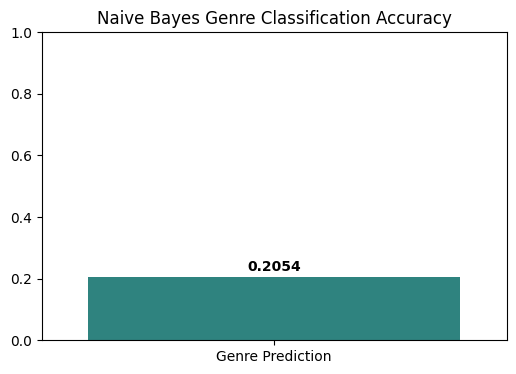

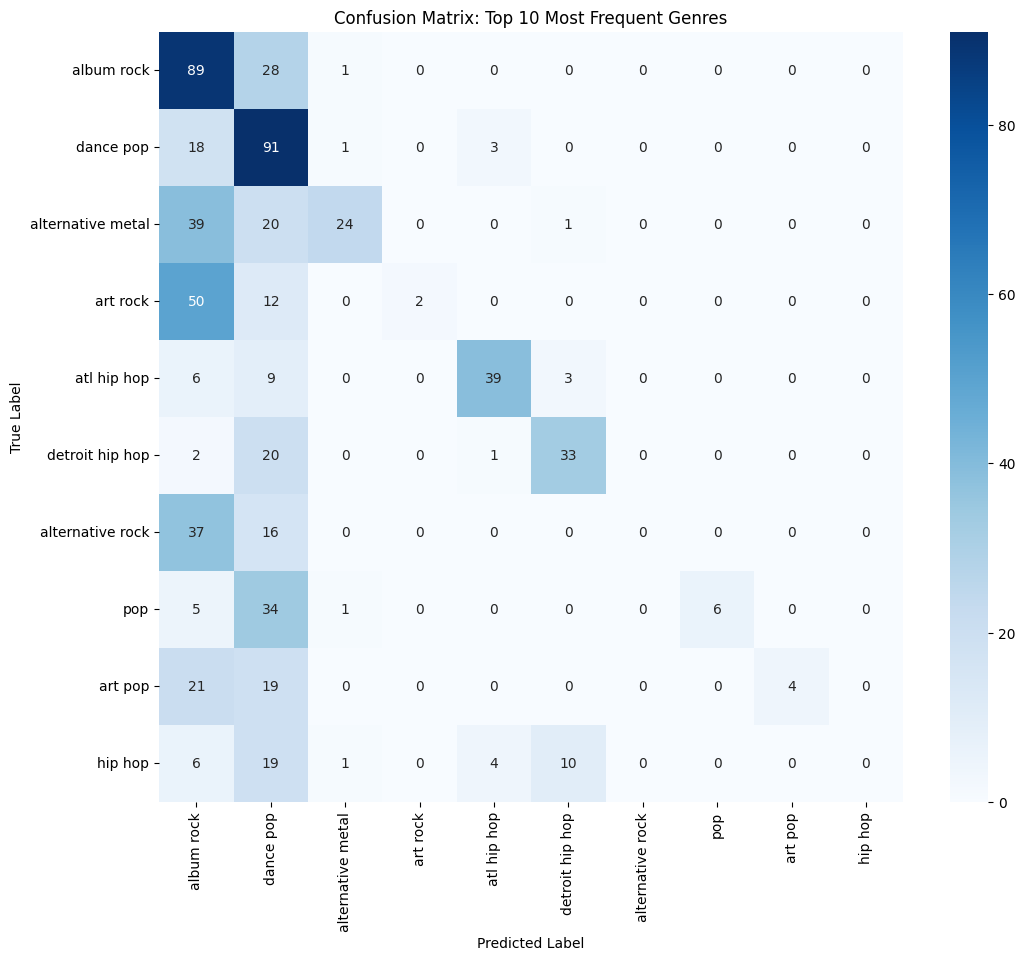

Full Classification Report (Top 10 Genres Only):
                   precision    recall  f1-score   support

       album rock       0.33      0.75      0.46       118
        dance pop       0.34      0.81      0.48       113
alternative metal       0.86      0.29      0.43        84
         art rock       1.00      0.03      0.06        64
      atl hip hop       0.83      0.68      0.75        57
  detroit hip hop       0.70      0.59      0.64        56
 alternative rock       0.00      0.00      0.00        53
              pop       1.00      0.13      0.23        46
          art pop       1.00      0.09      0.17        44
          hip hop       0.00      0.00      0.00        40

         accuracy                           0.43       675
        macro avg       0.61      0.34      0.32       675
     weighted avg       0.58      0.43      0.36       675



c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Philipp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [89]:
# 1. Accuracy Bar Chart
plt.figure(figsize=(6, 4))
sns.barplot(x=['Genre Prediction'], y=[acc_genre], palette='viridis', hue=['Genre Prediction'], legend=False)
plt.title('Naive Bayes Genre Classification Accuracy')
plt.ylim(0, 1)
plt.text(0, acc_genre + 0.02, f"{acc_genre:.4f}", ha="center", fontweight='bold')
plt.show()

# 2. Confusion Matrix for Top 10 Genres
top_10_genres = df_genre_task['primary_genre'].value_counts().nlargest(10).index
mask = np.isin(y_test_raw, top_10_genres) & np.isin(label_encoder.inverse_transform(y_pred_genre), top_10_genres)

if np.any(mask):
    y_test_top = y_test_raw[mask]
    y_pred_top = label_encoder.inverse_transform(y_pred_genre)[mask]
    
    cm = confusion_matrix(y_test_top, y_pred_top, labels=top_10_genres)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=top_10_genres, yticklabels=top_10_genres)
    plt.title('Confusion Matrix: Top 10 Most Frequent Genres')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# 3. Full Classification Report (Text)
print("Full Classification Report (Top 10 Genres Only):")
print(classification_report(y_test_raw[mask], label_encoder.inverse_transform(y_pred_genre)[mask], labels=top_10_genres))

### 7) Summary of Findings

#### Summary:
- **Lyrical Genre Specificity**: The model demonstrates that lyrics are genre-specific, allowing for predictive modeling using Naive Bayes.
- **Confusion Matrix Insights**: The confusion matrix reveals which genres are frequently confused by the model, providing insight into overlapping lyrical themes (e.g., Pop vs. Dance Pop).
- **NLP Impact**: Proper preprocessing (cleaning, stop word removal, lemmatization) is crucial for making text data readable for machine learning models.

#### Limitations:
- **Contextual Loss**: Bag-of-words models like Naive Bayes ignore word order. Future iterations could use **N-grams** to capture more lyrical nuance.
- **Vocabulary Size**: The model is limited by the vocabulary present in the training set.